In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Libraries imported")

✅ Libraries imported


In [2]:
df = pd.read_csv('../data/olist_merged.csv', parse_dates=['order_purchase_timestamp'])

df = df[df['order_status'] == 'delivered']

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print("✅ Data loaded!")
print(f"Total orders: {df['order_id'].nunique():,}")
print(f"Total customers: {df['customer_unique_id'].nunique():,}")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")

✅ Data loaded!
Total orders: 96,478
Total customers: 93,358
Date range: 2016-09-15 to 2018-08-29



1. RFM ANALYSIS - Customer Segmentation





📊 RFM Segmentation Summary:
----------------------------------------
   Others: 56,183 customers (60.2%)
      Avg Spending: $0K
      Avg Frequency: 1.0x

   Potential: 8,655 customers (9.3%)
      Avg Spending: $0K
      Avg Frequency: 1.0x

   Loyal Customers: 8,626 customers (9.2%)
      Avg Spending: $0K
      Avg Frequency: 1.0x

   At Risk: 7,748 customers (8.3%)
      Avg Spending: $0K
      Avg Frequency: 1.0x

   Champions: 6,220 customers (6.7%)
      Avg Spending: $0K
      Avg Frequency: 1.2x

   New Customers: 5,926 customers (6.3%)
      Avg Spending: $0K
      Avg Frequency: 1.0x

✅ Saved: ../images/rfm_analysis.png


In [3]:
print("\n" + "="*60)
print("1. RFM ANALYSIS - Customer Segmentation")
print("="*60)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'last_purchase', 'frequency', 'monetary']

today = df['order_purchase_timestamp'].max()
rfm['recency'] = (today - rfm['last_purchase']).dt.days

rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=['4', '3', '2', '1'])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=['1', '2', '3', '4'])

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

def rfm_segment(row):
    if row['rfm_score'] in ['444', '443', '434', '344']:
        return 'Champions'
    elif row['rfm_score'] in ['442', '441', '432', '431', '422', '421']:
        return 'Loyal Customers'
    elif row['rfm_score'] in ['333', '334', '343', '433', '342', '324']:
        return 'Potential'
    elif row['rfm_score'] in ['411', '412', '421', '311', '312']:
        return 'New Customers'
    elif row['rfm_score'] in ['111', '112', '121', '122', '131']:
        return 'At Risk'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

segment_counts = rfm['segment'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#5CB85C', '#D9534F', '#6C757D']
bars = ax1.bar(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)])
ax1.set_title('Customer Segmentation by RFM', fontsize=12, fontweight='bold')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Number of Customers')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

for bar, val in zip(bars, segment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}', ha='center', fontsize=9)

segment_monetary = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)
bars = ax2.bar(segment_monetary.index, segment_monetary / 1000, color=colors[:len(segment_monetary)])
ax2.set_title('Average Spending by Segment (in $K)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Average Spending ($K)')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

for bar, val in zip(bars, segment_monetary / 1000):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'${val:.0f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 RFM Segmentation Summary:")
print("-"*40)
for seg, count in segment_counts.items():
    pct = count/len(rfm)*100
    print(f"   {seg}: {count:,} customers ({pct:.1f}%)")
    print(f"      Avg Spending: ${segment_monetary[seg]/1000:.0f}K")
    print(f"      Avg Frequency: {rfm[rfm['segment']==seg]['frequency'].mean():.1f}x")
    print()

print("✅ Saved: ../images/rfm_analysis.png")


2. REPEAT PURCHASE ANALYSIS


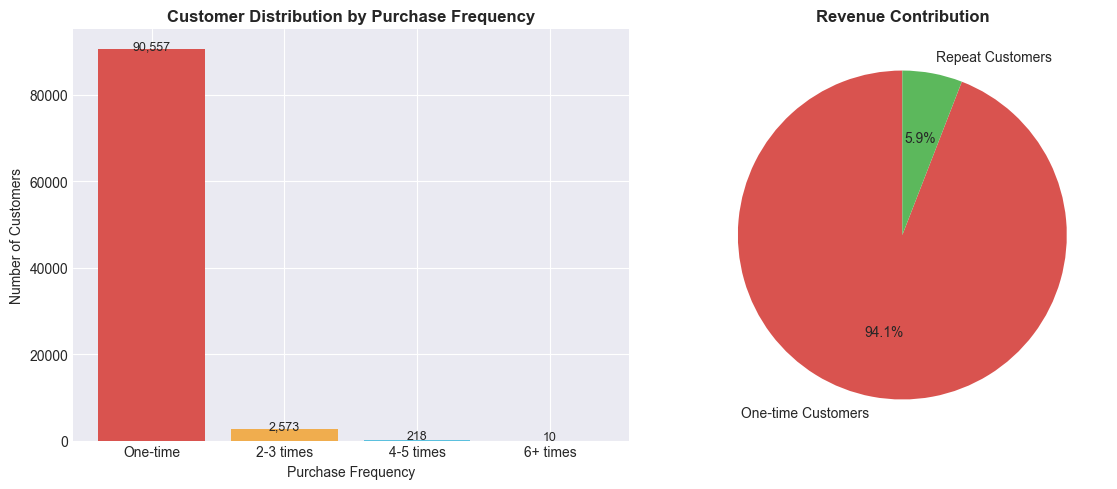


📊 Repeat Purchase Summary:
----------------------------------------
   One-time customers: 90,557 (97.0%)
   Repeat customers: 2,801 (3.0%)

   Average orders from repeat customers: 2.1x
   Average LTV repeat customers: $292
   Average LTV one-time customers: $144

✅ Saved: ../images/repeat_purchase.png


In [4]:
print("\n" + "="*60)
print("2. REPEAT PURCHASE ANALYSIS")
print("="*60)

customer_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_id', 'order_count']

customer_orders['type'] = pd.cut(customer_orders['order_count'], 
                                  bins=[0, 1, 2, 5, 100], 
                                  labels=['One-time', '2-3 times', '4-5 times', '6+ times'])

repeat_analysis = customer_orders.groupby('type').agg({
    'customer_id': 'count',
    'order_count': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#D9534F', '#F0AD4E', '#5BC0DE', '#5CB85C']
bars = ax1.bar(repeat_analysis['type'], repeat_analysis['customer_id'], color=colors)
ax1.set_title('Customer Distribution by Purchase Frequency', fontsize=12, fontweight='bold')
ax1.set_xlabel('Purchase Frequency')
ax1.set_ylabel('Number of Customers')

for bar, val in zip(bars, repeat_analysis['customer_id']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}', ha='center', fontsize=9)

repeat_customers = customer_orders[customer_orders['order_count'] > 1]['customer_id'].tolist()
df['is_repeat'] = df['customer_unique_id'].isin(repeat_customers)

repeat_revenue = df.groupby('is_repeat')['price'].sum() / 1_000_000
total_revenue = df['price'].sum() / 1_000_000

labels = ['One-time Customers', 'Repeat Customers']
ax2.pie(repeat_revenue.values, labels=labels, autopct='%1.1f%%', 
        colors=['#D9534F', '#5CB85C'], startangle=90)
ax2.set_title('Revenue Contribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/repeat_purchase.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Repeat Purchase Summary:")
print("-"*40)
one_time = customer_orders[customer_orders['order_count'] == 1].shape[0]
repeat = customer_orders[customer_orders['order_count'] > 1].shape[0]
print(f"   One-time customers: {one_time:,} ({one_time/len(customer_orders)*100:.1f}%)")
print(f"   Repeat customers: {repeat:,} ({repeat/len(customer_orders)*100:.1f}%)")
print(f"\n   Average orders from repeat customers: {customer_orders[customer_orders['order_count'] > 1]['order_count'].mean():.1f}x")
print(f"   Average LTV repeat customers: ${df[df['is_repeat']]['price'].sum()/repeat:,.0f}")
print(f"   Average LTV one-time customers: ${df[~df['is_repeat']]['price'].sum()/one_time:,.0f}")

print("\n✅ Saved: ../images/repeat_purchase.png")


3. TIME PATTERNS ANALYSIS


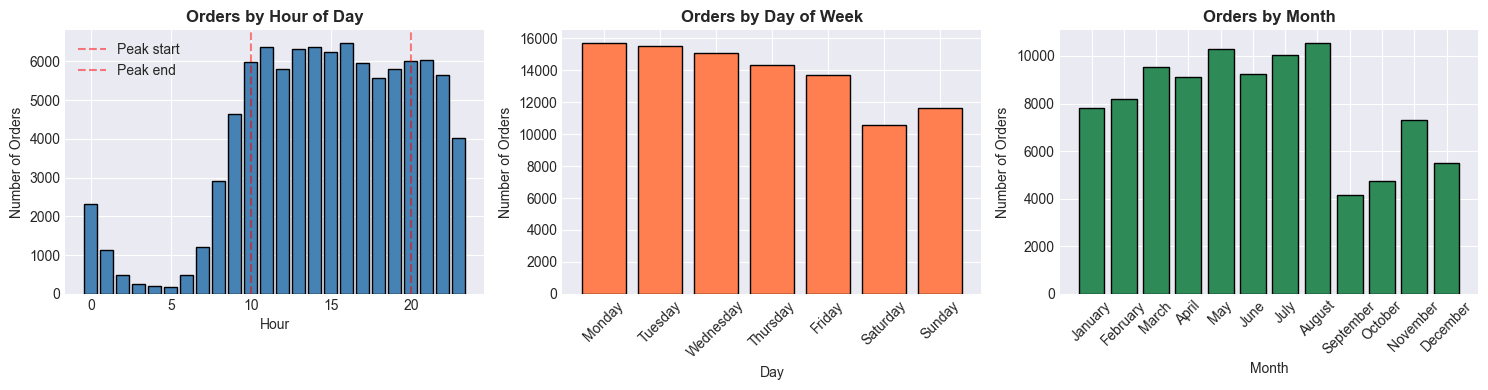


📊 Time Patterns Summary:
----------------------------------------
   Peak order hour: 16:00 (6,476 orders)
   Peak order day: Monday (15,701 orders)
   Peak order month: August (10,544 orders)

   Weekend vs Weekday:
      Weekend orders: 22,190
      Weekday orders: 74,288
      Ratio: 3.3x more on weekdays

✅ Saved: ../images/time_patterns.png


In [6]:
print("\n" + "="*60)
print("3. TIME PATTERNS ANALYSIS")
print("="*60)

df['hour'] = df['order_purchase_timestamp'].dt.hour
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['month_name'] = df['order_purchase_timestamp'].dt.month_name()
df['month_num'] = df['order_purchase_timestamp'].dt.month

hourly_orders = df.groupby('hour')['order_id'].nunique().reset_index()
daily_orders = df.groupby('day_of_week')['order_id'].nunique().reset_index()
monthly_orders = df.groupby('month_name')['order_id'].nunique().reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_orders['day_of_week'] = pd.Categorical(daily_orders['day_of_week'], categories=day_order, ordered=True)
daily_orders = daily_orders.sort_values('day_of_week')

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_orders['month_name'] = pd.Categorical(monthly_orders['month_name'], categories=month_order, ordered=True)
monthly_orders = monthly_orders.sort_values('month_name')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(hourly_orders['hour'], hourly_orders['order_id'], color='steelblue', edgecolor='black')
axes[0].set_title('Orders by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Orders')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.5, label='Peak start')
axes[0].axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Peak end')
axes[0].legend()

axes[1].bar(daily_orders['day_of_week'], daily_orders['order_id'], color='coral', edgecolor='black')
axes[1].set_title('Orders by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Orders')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

axes[2].bar(monthly_orders['month_name'], monthly_orders['order_id'], color='seagreen', edgecolor='black')
axes[2].set_title('Orders by Month', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Orders')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../images/time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_orders.loc[hourly_orders['order_id'].idxmax(), 'hour']
peak_day = daily_orders.loc[daily_orders['order_id'].idxmax(), 'day_of_week']
peak_month = monthly_orders.loc[monthly_orders['order_id'].idxmax(), 'month_name']

weekend = daily_orders[daily_orders['day_of_week'].isin(['Saturday', 'Sunday'])]['order_id'].sum()
weekday = daily_orders[~daily_orders['day_of_week'].isin(['Saturday', 'Sunday'])]['order_id'].sum()

print("\n📊 Time Patterns Summary:")
print("-"*40)
print(f"   Peak order hour: {peak_hour}:00 ({hourly_orders['order_id'].max():,} orders)")
print(f"   Peak order day: {peak_day} ({daily_orders['order_id'].max():,} orders)")
print(f"   Peak order month: {peak_month} ({monthly_orders['order_id'].max():,} orders)")
print(f"\n   Weekend vs Weekday:")
print(f"      Weekend orders: {weekend:,}")
print(f"      Weekday orders: {weekday:,}")
print(f"      Ratio: {weekday/weekend:.1f}x more on weekdays")

print("\n✅ Saved: ../images/time_patterns.png")


4. SELLER PERFORMANCE ANALYSIS


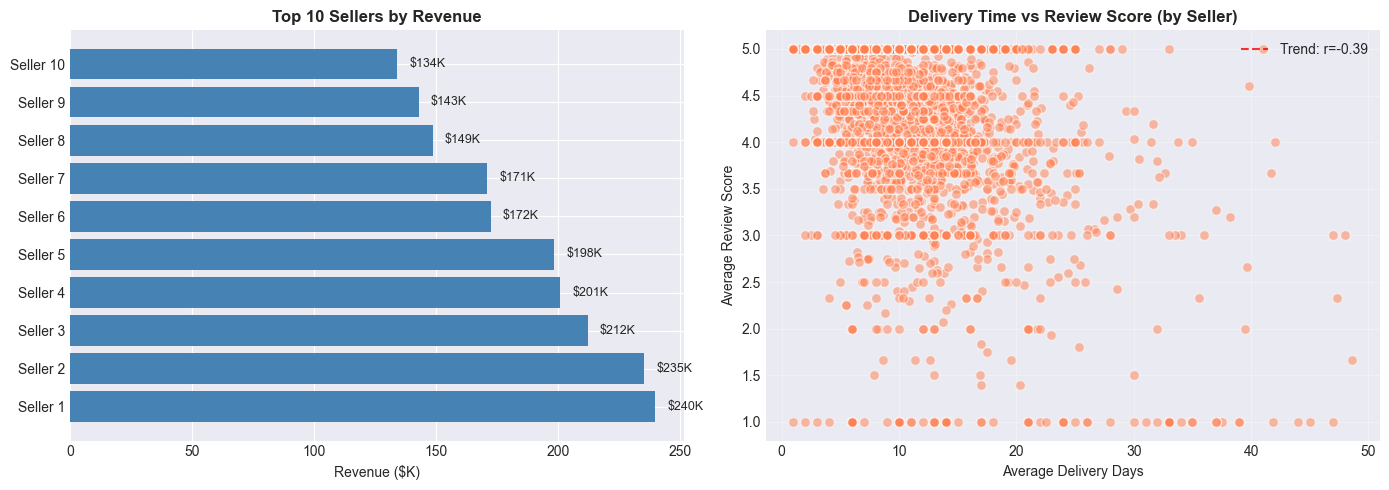


📊 Seller Performance Summary:
----------------------------------------
   Total sellers: 2,970
   Average revenue per seller: $4,672
   Average rating per seller: 4.15★
   Average delivery per seller: 11.7 days

   Top seller revenue: $240K
   Top seller orders: 348
   Top seller rating: 4.12★

✅ Saved: ../images/seller_performance.png


In [7]:
print("\n" + "="*60)
print("4. SELLER PERFORMANCE ANALYSIS")
print("="*60)

seller_performance = df.groupby('seller_id').agg({
    'order_id': 'nunique',
    'price': 'sum',
    'review_score': 'mean',
    'delivery_days': 'mean'
}).reset_index()

seller_performance.columns = ['seller_id', 'total_orders', 'total_revenue', 'avg_review', 'avg_delivery']
seller_performance = seller_performance.sort_values('total_revenue', ascending=False)

top_sellers = seller_performance.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.barh(range(len(top_sellers)), top_sellers['total_revenue'] / 1000, color='steelblue')
ax1.set_yticks(range(len(top_sellers)))
ax1.set_yticklabels([f'Seller {i+1}' for i in range(len(top_sellers))])
ax1.set_title('Top 10 Sellers by Revenue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Revenue ($K)')

for bar, val in zip(bars, top_sellers['total_revenue'] / 1000):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             f'${val:.0f}K', va='center', fontsize=9)

seller_filtered = seller_performance[seller_performance['avg_delivery'] < 50]
ax2.scatter(seller_filtered['avg_delivery'], seller_filtered['avg_review'], 
            alpha=0.5, s=50, c='coral', edgecolors='white')
ax2.set_title('Delivery Time vs Review Score (by Seller)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average Delivery Days')
ax2.set_ylabel('Average Review Score')
ax2.grid(True, alpha=0.3)

z = np.polyfit(seller_filtered['avg_delivery'], seller_filtered['avg_review'], 1)
p = np.poly1d(z)
ax2.plot(seller_filtered['avg_delivery'], p(seller_filtered['avg_delivery']), 
         "r--", alpha=0.8, label=f'Trend: r={seller_filtered["avg_delivery"].corr(seller_filtered["avg_review"]):.2f}')
ax2.legend()

plt.tight_layout()
plt.savefig('../images/seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Seller Performance Summary:")
print("-"*40)
print(f"   Total sellers: {seller_performance.shape[0]:,}")
print(f"   Average revenue per seller: ${seller_performance['total_revenue'].mean():,.0f}")
print(f"   Average rating per seller: {seller_performance['avg_review'].mean():.2f}★")
print(f"   Average delivery per seller: {seller_performance['avg_delivery'].mean():.1f} days")
print(f"\n   Top seller revenue: ${top_sellers.iloc[0]['total_revenue']/1000:.0f}K")
print(f"   Top seller orders: {top_sellers.iloc[0]['total_orders']:,}")
print(f"   Top seller rating: {top_sellers.iloc[0]['avg_review']:.2f}★")

print("\n✅ Saved: ../images/seller_performance.png")


4. SELLER PERFORMANCE ANALYSIS


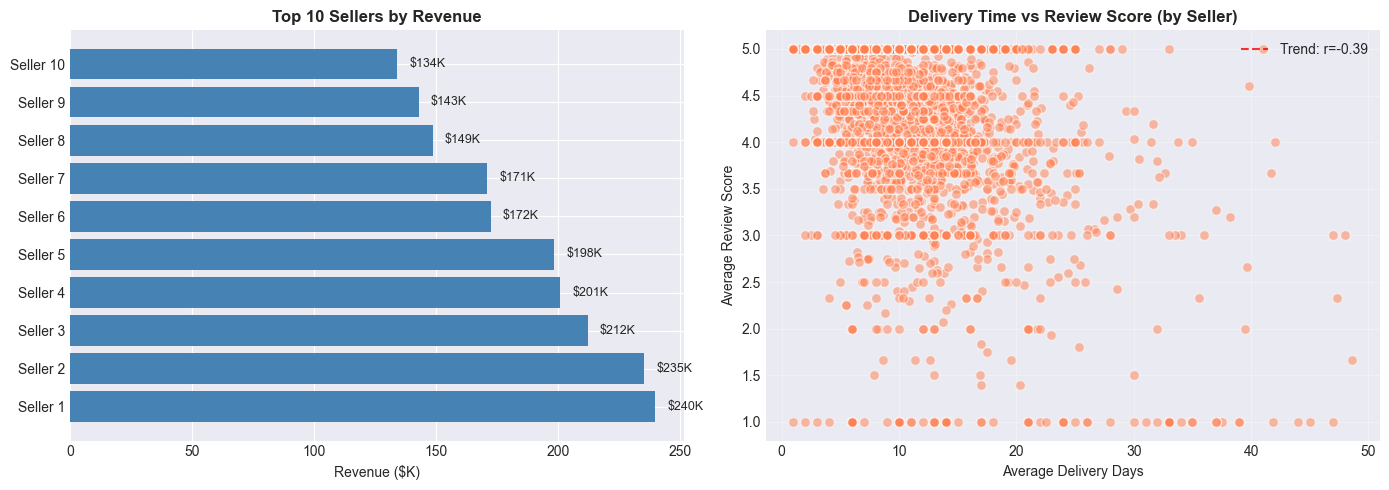


📊 Seller Performance Summary:
----------------------------------------
   Total sellers: 2,970
   Average revenue per seller: $4,672
   Average rating per seller: 4.15★
   Average delivery per seller: 11.7 days

   Top seller revenue: $240K
   Top seller orders: 348
   Top seller rating: 4.12★

✅ Saved: ../images/seller_performance.png


In [8]:
print("\n" + "="*60)
print("4. SELLER PERFORMANCE ANALYSIS")
print("="*60)

seller_performance = df.groupby('seller_id').agg({
    'order_id': 'nunique',
    'price': 'sum',
    'review_score': 'mean',
    'delivery_days': 'mean'
}).reset_index()

seller_performance.columns = ['seller_id', 'total_orders', 'total_revenue', 'avg_review', 'avg_delivery']
seller_performance = seller_performance.sort_values('total_revenue', ascending=False)

top_sellers = seller_performance.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.barh(range(len(top_sellers)), top_sellers['total_revenue'] / 1000, color='steelblue')
ax1.set_yticks(range(len(top_sellers)))
ax1.set_yticklabels([f'Seller {i+1}' for i in range(len(top_sellers))])
ax1.set_title('Top 10 Sellers by Revenue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Revenue ($K)')

for bar, val in zip(bars, top_sellers['total_revenue'] / 1000):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             f'${val:.0f}K', va='center', fontsize=9)

seller_filtered = seller_performance[seller_performance['avg_delivery'] < 50]
ax2.scatter(seller_filtered['avg_delivery'], seller_filtered['avg_review'], 
            alpha=0.5, s=50, c='coral', edgecolors='white')
ax2.set_title('Delivery Time vs Review Score (by Seller)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average Delivery Days')
ax2.set_ylabel('Average Review Score')
ax2.grid(True, alpha=0.3)

z = np.polyfit(seller_filtered['avg_delivery'], seller_filtered['avg_review'], 1)
p = np.poly1d(z)
ax2.plot(seller_filtered['avg_delivery'], p(seller_filtered['avg_delivery']), 
         "r--", alpha=0.8, label=f'Trend: r={seller_filtered["avg_delivery"].corr(seller_filtered["avg_review"]):.2f}')
ax2.legend()

plt.tight_layout()
plt.savefig('../images/seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Seller Performance Summary:")
print("-"*40)
print(f"   Total sellers: {seller_performance.shape[0]:,}")
print(f"   Average revenue per seller: ${seller_performance['total_revenue'].mean():,.0f}")
print(f"   Average rating per seller: {seller_performance['avg_review'].mean():.2f}★")
print(f"   Average delivery per seller: {seller_performance['avg_delivery'].mean():.1f} days")
print(f"\n   Top seller revenue: ${top_sellers.iloc[0]['total_revenue']/1000:.0f}K")
print(f"   Top seller orders: {top_sellers.iloc[0]['total_orders']:,}")
print(f"   Top seller rating: {top_sellers.iloc[0]['avg_review']:.2f}★")

print("\n✅ Saved: ../images/seller_performance.png")


5. FREIGHT COST ANALYSIS


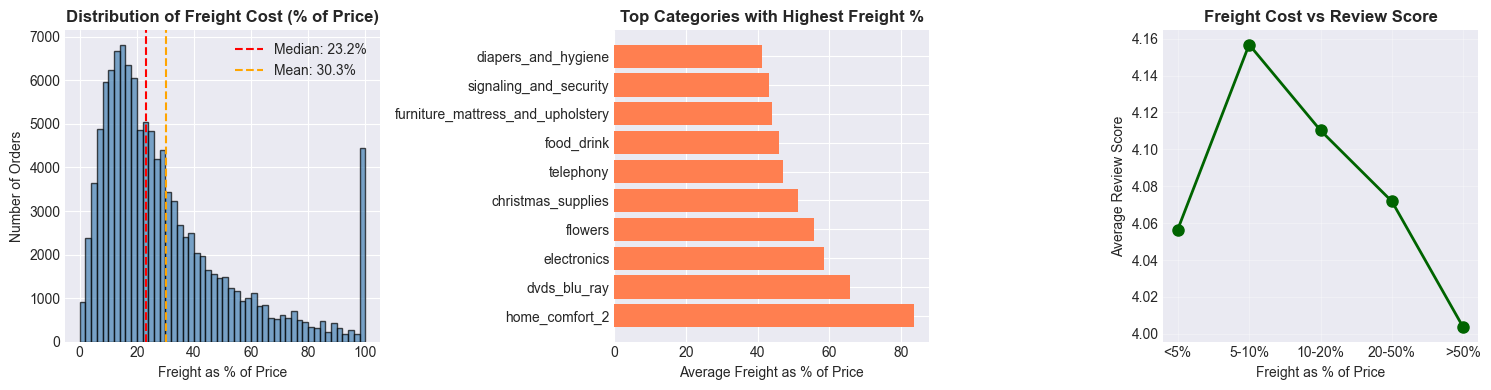


📊 Freight Analysis Summary:
----------------------------------------
   Average freight cost: $19.98
   Average freight as % of price: 30.3%
   Median freight as % of price: 23.2%

   Categories with highest freight %:
      1. home_comfort_2: 83.5%
      2. dvds_blu_ray: 65.7%
      3. electronics: 58.5%
      4. flowers: 55.8%
      5. christmas_supplies: 51.3%

   Impact on reviews:
      <5%: 4.06★
      5-10%: 4.16★
      10-20%: 4.11★
      20-50%: 4.07★
      >50%: 4.00★

✅ Saved: ../images/freight_analysis.png


In [9]:
print("\n" + "="*60)
print("5. FREIGHT COST ANALYSIS")
print("="*60)

df['freight_ratio'] = df['freight_value'] / df['price'] * 100
df['freight_ratio'] = df['freight_ratio'].clip(upper=100)

df['freight_category'] = pd.cut(df['freight_ratio'], 
                                  bins=[0, 5, 10, 20, 50, 100], 
                                  labels=['Very Low (<5%)', 'Low (5-10%)', 'Medium (10-20%)', 'High (20-50%)', 'Very High (>50%)'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['freight_ratio'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['freight_ratio'].median(), color='red', linestyle='--', 
                label=f'Median: {df["freight_ratio"].median():.1f}%')
axes[0].axvline(df['freight_ratio'].mean(), color='orange', linestyle='--', 
                label=f'Mean: {df["freight_ratio"].mean():.1f}%')
axes[0].set_title('Distribution of Freight Cost (% of Price)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Freight as % of Price')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

category_freight = df.groupby('product_category_name_english')['freight_ratio'].mean().nlargest(10)
axes[1].barh(category_freight.index, category_freight.values, color='coral')
axes[1].set_title('Top Categories with Highest Freight %', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Freight as % of Price')

freight_bins = pd.cut(df['freight_ratio'], bins=[0, 5, 10, 20, 50, 100])
freight_review = df.groupby(freight_bins)['review_score'].mean()
bin_labels = ['<5%', '5-10%', '10-20%', '20-50%', '>50%']
axes[2].plot(range(len(freight_review)), freight_review.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[2].set_xticks(range(len(freight_review)))
axes[2].set_xticklabels(bin_labels)
axes[2].set_title('Freight Cost vs Review Score', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Freight as % of Price')
axes[2].set_ylabel('Average Review Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/freight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Freight Analysis Summary:")
print("-"*40)
print(f"   Average freight cost: ${df['freight_value'].mean():.2f}")
print(f"   Average freight as % of price: {df['freight_ratio'].mean():.1f}%")
print(f"   Median freight as % of price: {df['freight_ratio'].median():.1f}%")
print(f"\n   Categories with highest freight %:")
for i, (cat, val) in enumerate(category_freight.head(5).items()):
    print(f"      {i+1}. {cat}: {val:.1f}%")
print(f"\n   Impact on reviews:")
for i, label in enumerate(bin_labels):
    print(f"      {label}: {freight_review.iloc[i]:.2f}★")

print("\n✅ Saved: ../images/freight_analysis.png")

In [10]:
print("\n" + "="*60)
print("✅ ADVANCED ANALYSIS COMPLETE!")
print("="*60)

print("\n📁 ALL FILES SAVED:")
print("-"*40)
print("   ../images/rfm_analysis.png")
print("   ../images/repeat_purchase.png")
print("   ../images/time_patterns.png")
print("   ../images/seller_performance.png")
print("   ../images/freight_analysis.png")

total_revenue_sum = df['price'].sum() / 1_000_000
repeat_revenue_sum = df[df['is_repeat']]['price'].sum() / 1_000_000

print("\n📊 KEY INSIGHTS FROM ADVANCED ANALYSIS:")
print("-"*40)
print("1. RFM Segmentation:")
print(f"   - {segment_counts.index[0]} customers: {segment_counts.iloc[0]:,} ({segment_counts.iloc[0]/len(rfm)*100:.1f}%)")
print(f"   - At Risk customers: {segment_counts.get('At Risk', 0):,}")
print("\n2. Repeat Purchase:")
print(f"   - Only {repeat/len(customer_orders)*100:.1f}% customers buy again")
print(f"   - Repeat customers spend {repeat_revenue_sum/total_revenue_sum*100:.1f}% of revenue")
print("\n3. Time Patterns:")
print(f"   - Peak hour: {peak_hour}:00")
print(f"   - Peak month: {peak_month}")
print(f"   - Weekday orders: {weekday/weekend:.1f}x weekend")
print("\n4. Seller Performance:")
print(f"   - Correlation delivery vs review: {seller_filtered['avg_delivery'].corr(seller_filtered['avg_review']):.2f}")
print("\n5. Freight Analysis:")
print(f"   - Average freight: {df['freight_ratio'].mean():.1f}% of product price")
print(f"   - High freight (>20%) leads to {freight_review.iloc[3]:.2f}★ vs {freight_review.iloc[0]:.2f}★ for low freight")

print("\n" + "="*60)
print("🎉 ALL NOTEBOOKS COMPLETE!")
print("="*60)


✅ ADVANCED ANALYSIS COMPLETE!

📁 ALL FILES SAVED:
----------------------------------------
   ../images/rfm_analysis.png
   ../images/repeat_purchase.png
   ../images/time_patterns.png
   ../images/seller_performance.png
   ../images/freight_analysis.png

📊 KEY INSIGHTS FROM ADVANCED ANALYSIS:
----------------------------------------
1. RFM Segmentation:
   - Others customers: 56,183 (60.2%)
   - At Risk customers: 7,748

2. Repeat Purchase:
   - Only 3.0% customers buy again
   - Repeat customers spend 5.9% of revenue

3. Time Patterns:
   - Peak hour: 16:00
   - Peak month: August
   - Weekday orders: 3.3x weekend

4. Seller Performance:
   - Correlation delivery vs review: -0.39

5. Freight Analysis:
   - Average freight: 30.3% of product price
   - High freight (>20%) leads to 4.07★ vs 4.06★ for low freight

🎉 ALL NOTEBOOKS COMPLETE!
